<a href="https://colab.research.google.com/github/Abdul2611/Retail-Sales-Data-Analysis/blob/main/SalesAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
df = pd.read_csv('retail_sales.csv')
df

,Date,Product,Category,Unit_Price,Quantity,Store,Total_Amount
0,2023-04-13,Bag,Electronics,29838,4,Hyderabad,119352
1,2023-12-15,Shoes,Clothing,30419,1,Mumbai,30419
2,2023-09-28,Jacket,Accessories,8633,2,Kolkata,17266
3,2023-04-17,Tshirt,Accessories,5710,4,Hyderabad,22840
4,2023-03-13,Headphones,Clothing,18139,3,Pune,54417
...,...,...,...,...,...,...,...
995,2023-02-07,Mobile,Footwear,40686,4,Pune,162744
996,2023-10-20,Shoes,Footwear,20631,4,Bangalore,82524
997,2023-05-19,Shoes,Fragrance,18360,1,Pune,18360
998,2023-12-22,Shoes,Fragrance,1496,3,Mumbai,4488


In [38]:
df.head(11)

,Date,Product,Category,Unit_Price,Quantity,Store,Total_Amount
0,2023-04-13,Bag,Electronics,29838,4,Hyderabad,119352
1,2023-12-15,Shoes,Clothing,30419,1,Mumbai,30419
2,2023-09-28,Jacket,Accessories,8633,2,Kolkata,17266
3,2023-04-17,Tshirt,Accessories,5710,4,Hyderabad,22840
4,2023-03-13,Headphones,Clothing,18139,3,Pune,54417
5,2023-07-08,Perfume,Clothing,56344,3,Chennai,169032
6,2023-01-21,Jeans,Footwear,30819,2,Delhi,61638
7,2023-04-13,Laptop,Accessories,6108,3,Mumbai,18324
8,2023-05-02,Perfume,Fragrance,7096,1,Kolkata,7096
9,2023-08-03,Tshirt,Clothing,21480,4,Kolkata,85920


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Date          1000 non-null   object
 1   Product       1000 non-null   object
 2   Category      1000 non-null   object
 3   Unit_Price    1000 non-null   int64 
 4   Quantity      1000 non-null   int64 
 5   Store         1000 non-null   object
 6   Total_Amount  1000 non-null   int64 
dtypes: int64(3), object(4)
memory usage: 54.8+ KB


In [40]:
df.isnull().sum()

,0
Date,0
Product,0
Category,0
Unit_Price,0
Quantity,0
Store,0
Total_Amount,0


In [41]:
df.dtypes

,0
Date,object
Product,object
Category,object
Unit_Price,int64
Quantity,int64
Store,object
Total_Amount,int64


In [42]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
995,False
996,False
997,False
998,False


In [43]:
df['Date'] = pd.to_datetime(df['Date'])

In [44]:
df['Product'] = df['Product'].str.title()
df['Store'] = df['Store'].str.title()
df['Category'] = df['Category'].str.title()

In [45]:
df.drop_duplicates()

,Date,Product,Category,Unit_Price,Quantity,Store,Total_Amount
0,2023-04-13,Bag,Electronics,29838,4,Hyderabad,119352
1,2023-12-15,Shoes,Clothing,30419,1,Mumbai,30419
2,2023-09-28,Jacket,Accessories,8633,2,Kolkata,17266
3,2023-04-17,Tshirt,Accessories,5710,4,Hyderabad,22840
4,2023-03-13,Headphones,Clothing,18139,3,Pune,54417
...,...,...,...,...,...,...,...
995,2023-02-07,Mobile,Footwear,40686,4,Pune,162744
996,2023-10-20,Shoes,Footwear,20631,4,Bangalore,82524
997,2023-05-19,Shoes,Fragrance,18360,1,Pune,18360
998,2023-12-22,Shoes,Fragrance,1496,3,Mumbai,4488


In [46]:
df['Month'] = df['Date'].dt.to_period('M').astype(str)
df['Year'] = df['Date'].dt.year
df['Week'] = df['Date'].dt.isocalendar().week

In [47]:
df.describe()

,Date,Unit_Price,Quantity,Total_Amount,Year,Week
count,1000,1000.000000,1000.000000,1000.000000,1000.0,1000.0
mean,2023-07-01 13:22:04.800000,29765.342000,2.445000,72040.453000,2023.0,26.674
min,2023-01-01 00:00:00,438.000000,1.000000,576.000000,2023.0,1.0
25%,2023-04-08 00:00:00,15321.750000,1.000000,29330.000000,2023.0,14.0
50%,2023-07-01 12:00:00,28593.000000,2.000000,54130.000000,2023.0,27.0
75%,2023-09-27 06:00:00,44842.750000,3.000000,108276.000000,2023.0,39.0
max,2023-12-31 00:00:00,59986.000000,4.000000,239944.000000,2023.0,52.0
std,NaN,17216.683405,1.120817,56041.214159,0.0,14.876526


In [48]:
total_revenue = df['Total_Amount'].sum()
aov = df['Total_Amount'].mean()
total_orders = len(df)
total_qty = df['Quantity'].sum()

total_revenue, aov, total_orders, total_qty

(np.int64(72040453), np.float64(72040.453), 1000, np.int64(2445))

In [49]:
# Top products
top_products = (df.groupby('Product')['Total_Amount']
                .sum().sort_values(ascending=False).head(10))
print(top_products)

# Revenue by city
rev_by_city = (df.groupby('Store')['Total_Amount']
               .sum().sort_values(ascending=False))
print(rev_by_city)

# Monthly trend
rev_by_month = df.groupby('Month')['Total_Amount'].sum()
print(rev_by_month)


Product
Headphones    8305086
Jacket        8216379
Shoes         7519192
Tshirt        7191088
Mobile        7159371
Bag           7087134
Perfume       6747443
Watch         6621005
Jeans         6597908
Laptop        6595847
Name: Total_Amount, dtype: int64
Store
Kolkata      12325877
Pune         11725578
Chennai      10627517
Delhi         9756189
Mumbai        9636546
Hyderabad     9136071
Bangalore     8832675
Name: Total_Amount, dtype: int64
Month
2023-01    5614433
2023-02    5659730
2023-03    4518016
2023-04    7272475
2023-05    6640169
2023-06    6990207
2023-07    5285499
2023-08    7088970
2023-09    5646961
2023-10    4887810
2023-11    5707758
2023-12    6728425
Name: Total_Amount, dtype: int64


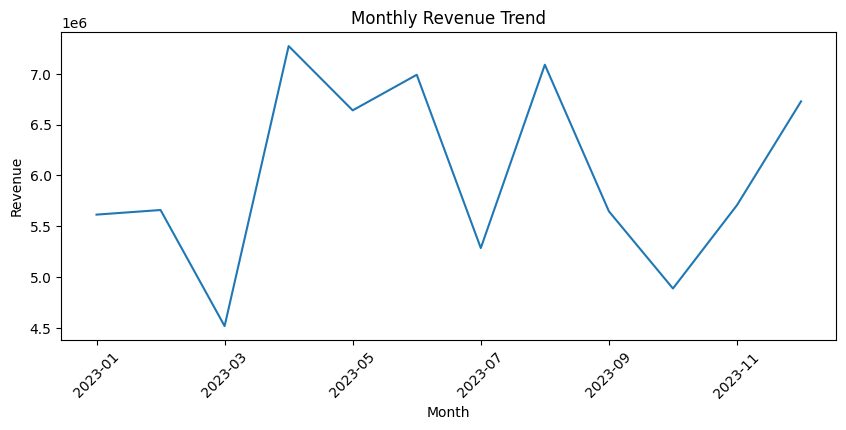

In [50]:
plt.figure(figsize=(10,4))
rev_by_month.plot(kind='line')
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

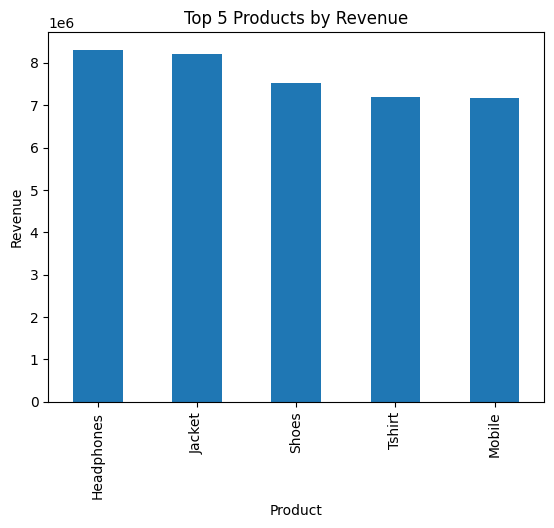

In [73]:
top_products.head(5).plot(kind='bar')
plt.title("Top 5 Products by Revenue")
plt.ylabel("Revenue")
plt.show()

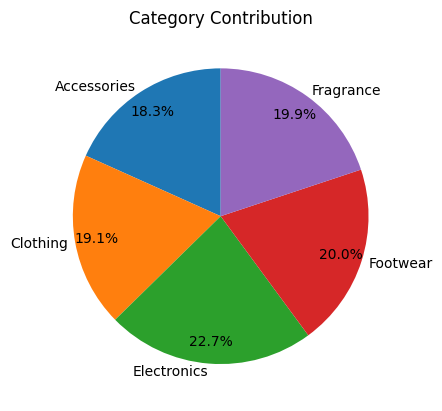

In [71]:
df.groupby('Category')['Total_Amount'].sum().plot(kind='pie',autopct="%1.1f%%",startangle=90,pctdistance=0.85,labeldistance=1.05)
plt.title("Category Contribution")
plt.ylabel("")
plt.show()

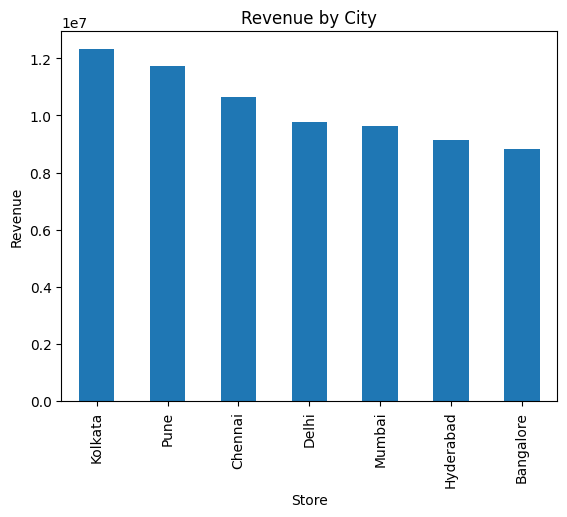

In [52]:
rev_by_city.plot(kind='bar')
plt.title("Revenue by City")
plt.ylabel("Revenue")
plt.show()

In [56]:
df[df['Unit_Price'] > 10000].groupby('Product')['Total_Amount'].sum()

,Total_Amount
Product,
Bag,6970850
Headphones,8104876
Jacket,8016453
Jeans,6312685
Laptop,6404021
Mobile,6896971
Perfume,6468414
Shoes,7255779
Tshirt,7029581


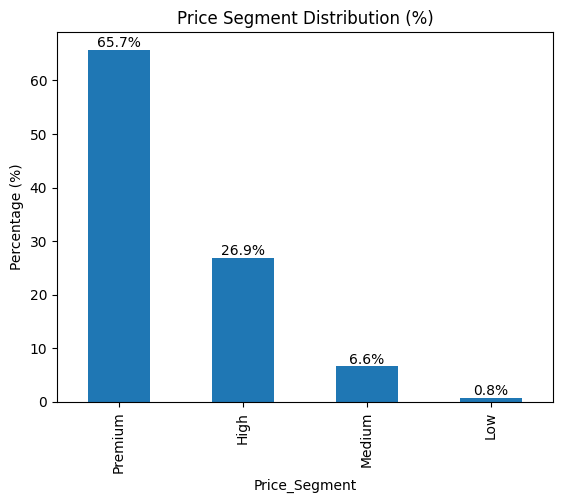

In [62]:
segment_counts = df['Price_Segment'].value_counts(normalize=True) * 100
segment_counts.plot(kind='bar',title="Price Segment Distribution (%)")

plt.ylabel("Percentage (%)")
for i, v in enumerate(segment_counts):
    plt.text(i, v, f"{v:.1f}%", ha='center', va='bottom')
plt.show()

In [68]:
print("Total Revenue:", total_revenue)
print("Avg Order Value:", aov)
print("Top Product:", top_products.index[0])
print("Top City:", rev_by_city.index[0])
print("Best Month:", rev_by_month.idxmax())

Total Revenue: 72040453
Avg Order Value: 72040.453
Top Product: Headphones
Top City: Kolkata
Best Month: 2023-04
